# Pip Intalls
Hi DIGIT 210! Dr. B here with some notes on pip installations to run this notebook:
Go out to your shell, **make sure you've activated your virtual environment** on your folder hosting this notebook. 

In your activated (.venv) at command line, run the following:

```shell
pip install "numpy<2.0"
pip install torch transformers
pip install --upgrade torch 
pip install ipywidgets
```



|<h2>Substack post:</h2>|<h1><a href="https://open.substack.com/pub/mikexcohen/p/llm-breakdown-16-tokenization-words" target="_blank">LLM breakdown 1/6: Tokenization (words to integers)</a></h1>|
|-|:-:|
|<h2>Teacher:<h2>|<h1>Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h1>|

<br>

<i>Using the code without reading the post may lead to confusion or errors.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import gridspec

# pytorch libraries
import torch
import torch.nn.functional as F

In [2]:
### Run this cell only if you're using "dark mode"

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'figure.facecolor': '#171717',
    'figure.edgecolor': '#171717',
    'axes.facecolor':   '#171717',
    'axes.edgecolor':   '#DDE2F4',
    'axes.labelcolor':  '#DDE2F4',
    'xtick.color':      '#DDE2F4',
    'ytick.color':      '#DDE2F4',
    'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

# Import GPT2's tokenizer

In [3]:
# GPT2 tokenizer
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
dir(tokenizer)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__bool__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_bos_token',
 '_add_eos_token',
 '_add_tokens',
 '_added_tokens_decoder',
 '_added_tokens_encoder',
 '_auto_class',
 '_convert_encoding',
 '_convert_id_to_token',
 '_convert_token_to_id_with_added_voc',
 '_decode',
 '_encode_plus',
 '_eventual_warn_about_too_long_sequence',
 '_extra_special_tokens',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_target_context_manager',
 '_merges',
 '_pad',
 '_pad_token_type_id',
 '_patch_mistral_regex',
 '_post_init',
 

In [4]:
# how many tokens in the lexicon?
tokenizer.vocab_size

50257

# Some random tokens

In [5]:
for t in np.random.randint(tokenizer.vocab_size,size=10):
  print(f'Token {t:>5} is "{tokenizer.decode([t])}"')

Token 21934 is "Sunday"
Token  7590 is " Brook"
Token 45603 is " Valerie"
Token  8497 is "hesis"
Token 18164 is " Feng"
Token 29590 is "alted"
Token  5801 is " rapid"
Token 13540 is " 1983"
Token 16702 is " loot"
Token 30041 is "eating"


# Common vs. uncommon letter pairs

In [6]:
print(tokenizer.encode('th'))
print(tokenizer.encode('tq'))

[400]
[83, 80]


# Tokenizing a sentence

In [7]:
txt = 'I like the longer-form posts on Substack.'

tokens = tokenizer.encode(txt)
print(f'The sentence contains {len(txt)} characters and {len(tokens)} tokens.\n')

print('  Index  |  Token')
print('---------+-----------')
for t in tokens:
  print(f'  {t:>5}  |  "{tokenizer.decode([t])}"')

The sentence contains 41 characters and 11 tokens.

  Index  |  Token
---------+-----------
     40  |  "I"
    588  |  " like"
    262  |  " the"
   2392  |  " longer"
     12  |  "-"
    687  |  "form"
   6851  |  " posts"
    319  |  " on"
  24944  |  " Subst"
    441  |  "ack"
     13  |  "."


# Importance of spaces

In [8]:
words = [ 'banana',' banana',' Banana',
          'substack',' substack',
          'like',' like' ]

for w in words:
  toks = tokenizer.encode(w)
  print(f'{len(toks)} tokens form "{w}" ({toks})')

2 tokens form "banana" ([3820, 2271])
1 tokens form " banana" ([25996])
1 tokens form " Banana" ([40058])
2 tokens form "substack" ([7266, 25558])
2 tokens form " substack" ([3293, 441])
1 tokens form "like" ([2339])
1 tokens form " like" ([588])


# Any r's in strawberry?

In [9]:
tokenizer.encode(' strawberry')
tokenizer.encode('r')

[81]

# Tokenization in different languages

In [10]:
languages = ['English','Spanish','Arabic','Persian','Lithuanian','Chinese','Tamil','Esperanto']

sentences = [ 'Blue towels are great because they remind you of the sea, although the sea is wet and towels work better when they are dry.',
              'Las toallas azules son geniales porque recuerdan al mar, aunque el mar está mojado y las toallas funcionan mejor cuando están secas.',
              'تعتبر المناشف الزرقاء رائعة لأنها تذكرك بالبحر، على الرغم من أن البحر مبلل والمناشف تعمل بشكل أفضل عندما تكون جافة.',
              'حوله‌های آبی عالی هستند زیرا شما را به یاد دریا می‌اندازند، اگرچه دریا مرطوب است و حوله‌ها وقتی خشک باشند بهتر عمل می‌کنند.',
              'Mėlyni rankšluosčiai puikūs, nes primena jūrą, nors jūra yra šlapia, o rankšluosčiai geriau tinka, kai yra sausi.',
              '蓝色毛巾很棒，因为它们会让您想起大海，尽管海水是湿的，而毛巾在干燥时效果更好。',
              'நீல நிற துண்டுகள் சிறந்தவை, ஏனென்றால் அவை கடலை நினைவூட்டுகின்றன, இருப்பினும் கடல் ஈரமாக இருக்கும், துண்டுகள் உலர்ந்திருக்கும் போது சிறப்பாக வேலை செய்யும்.',
              'Bluaj mantukoj estas bonegaj ĉar ili memorigas vin pri la maro, kvankam la maro estas malseka kaj mantukoj funkcias pli bone kiam ili estas sekaj.',
]

In [11]:
# table header
print(' Language  |  Chars  |  tokens ')
print('-'*31)

tokenCount = []
charCount = []

for lang,text in zip(languages,sentences):

  # tokenize the text
  tokens = tokenizer.encode(text)

  # print the result
  print(f'{lang:>10} |   {len(text):3}   |  {len(tokens):3}')

  tokenCount.append(len(tokens))
  charCount.append(len(text))

 Language  |  Chars  |  tokens 
-------------------------------
   English |   123   |   26
   Spanish |   132   |   44
    Arabic |   115   |  121
   Persian |   123   |  140
Lithuanian |   113   |   61
   Chinese |    39   |   90
     Tamil |   154   |  420
 Esperanto |   146   |   58


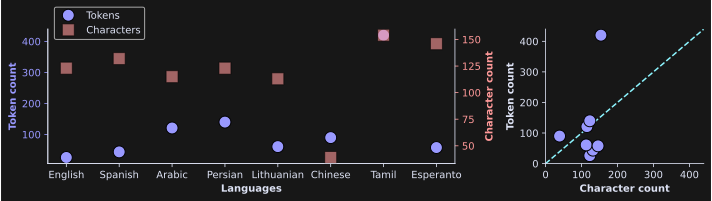

In [12]:
fig = plt.figure(figsize=(10,3))
gs = gridspec.GridSpec(1,3,figure=fig)
ax1 = fig.add_subplot(gs[:-1])
ax2 = fig.add_subplot(gs[-1])


# plot token count in blue
ax1.plot(tokenCount,'ko',markerfacecolor=[.6,.6,1],markersize=12,label='Tokens')
ax1.set(xlabel='Languages',xticks=range(len(languages)),xticklabels=languages)
ax1.set_ylabel('Token count',color=[.6,.6,1])
ax1.tick_params(axis='y',colors=[.6,.6,1])

# plot character count in red
axx = ax1.twinx()
axx.plot(charCount,'ks',markerfacecolor=[1,.6,.6,.6],markersize=12,label='Characters')
axx.spines['right'].set_visible(True)
axx.set_ylabel('Character count',color=[1,.6,.6])
axx.tick_params(axis='y',colors=[1,.6,.6])

# get both legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = axx.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, bbox_to_anchor=[.25,1.2])


ymax = np.max([np.max(tokenCount),np.max(charCount)])+20
ax2.plot(charCount,tokenCount,'ko',markerfacecolor=[.6,.6,1],markersize=12)
ax2.plot([0,ymax],[0,ymax],'--',color='#8cf5ff',zorder=-1)

ax2.set(xlabel='Character count',ylabel='Token count',xlim=[0,ymax],ylim=[0,ymax])

plt.tight_layout()
plt.show()

# Tokenization in BERT

In [13]:
from transformers import BertTokenizer
tokenizerB = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [14]:
words = [ 'banana',' banana',' Banana',
          'substack',' substack',
          'like',' like',
          '.', ',', ' ']

for w in words:
  toks = tokenizerB.encode(w,add_special_tokens=False)
  print(f'{len(toks)} tokens form "{w}" ({toks})')

1 tokens form "banana" ([15212])
1 tokens form " banana" ([15212])
1 tokens form " Banana" ([15212])
3 tokens form "substack" ([4942, 9153, 3600])
3 tokens form " substack" ([4942, 9153, 3600])
1 tokens form "like" ([2066])
1 tokens form " like" ([2066])
1 tokens form "." ([1012])
1 tokens form "," ([1010])
0 tokens form " " ([])
